In [5]:
# Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "../../datasets/processed/cpcb_historical_clean.csv"
OUT_PATH = "../../datasets/processed/aqi_hourly_clean.csv"

df = pd.read_csv(RAW_PATH)
df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])
pollutants = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
df.shape

(35974, 13)

In [6]:
# Collapse long format (1 row per station+timestamp+pollutant) into wide format

wide = df.pivot_table(index=['location_name', 'datetimeLocal'],
    columns='parameter',
    values='value',
    aggfunc='mean').reset_index()
wide = wide.sort_values(['location_name', 'datetimeLocal'])
print(wide.shape)
wide.head()

(6031, 8)


parameter,location_name,datetimeLocal,co,no2,o3,pm10,pm25,so2
0,"Ballygunge, Kolkata - WBPCB",2022-01-01 13:00:00+05:30,460.0,17.1,98.98,139.4,87.8,27.52
1,"Ballygunge, Kolkata - WBPCB",2022-01-01 14:00:00+05:30,450.0,17.5,104.94,131.9,73.0,27.79
2,"Ballygunge, Kolkata - WBPCB",2022-01-01 17:00:00+05:30,730.0,31.9,49.35,117.0,64.7,30.46
3,"Ballygunge, Kolkata - WBPCB",2022-01-01 18:00:00+05:30,1320.0,53.3,11.90,131.0,60.4,28.42
4,"Ballygunge, Kolkata - WBPCB",2022-01-02 06:00:00+05:30,550.0,17.5,20.26,127.9,78.9,13.81


In [7]:
# Resample to a consistent hourly grid per station

def process_station(g):
    g = g.set_index('datetimeLocal').sort_index()
    g = g[pollutants].resample('1h').mean()
    g = g.interpolate(method='time', limit=3, limit_direction='both')
    return g

resampled = (
    wide.groupby('location_name', group_keys=True)
        .apply(process_station, include_groups=False)
        .reset_index()
)
print(resampled.shape)
resampled.isna().sum()

(17846, 8)


parameter
location_name        0
datetimeLocal        0
co               10507
no2              10501
o3               10505
pm10             10506
pm25             10501
so2              10498
dtype: int64

In [8]:
# CPCB Averaging Windows

def add_rolling_averages(g):
    g = g.copy()
    g['pm25_24h'] = g['pm25'].rolling(24, min_periods=12).mean()
    g['pm10_24h'] = g['pm10'].rolling(24, min_periods=12).mean()
    g['no2_24h']  = g['no2'].rolling(24, min_periods=12).mean()
    g['so2_24h']  = g['so2'].rolling(24, min_periods=12).mean()
    g['co_8h']    = g['co'].rolling(8, min_periods=4).mean() / 1000.0  # µg/m³ -> mg/m³
    g['o3_8h']    = g['o3'].rolling(8, min_periods=4).mean()
    return g

resampled = pd.concat([add_rolling_averages(g) for _, g in resampled.groupby('location_name')]).reset_index(drop=True)
resampled.head()

parameter,location_name,datetimeLocal,co,no2,o3,pm10,pm25,so2,pm25_24h,pm10_24h,no2_24h,so2_24h,co_8h,o3_8h
0,"Ballygunge, Kolkata - WBPCB",2022-01-01 13:00:00+05:30,460.000000,17.1,98.98,139.400000,87.800000,27.52,NaN,NaN,NaN,NaN,NaN,NaN
1,"Ballygunge, Kolkata - WBPCB",2022-01-01 14:00:00+05:30,450.000000,17.5,104.94,131.900000,73.000000,27.79,NaN,NaN,NaN,NaN,NaN,NaN
2,"Ballygunge, Kolkata - WBPCB",2022-01-01 15:00:00+05:30,543.333333,22.3,86.41,126.933333,70.233333,28.68,NaN,NaN,NaN,NaN,NaN,NaN
3,"Ballygunge, Kolkata - WBPCB",2022-01-01 16:00:00+05:30,636.666667,27.1,67.88,121.966667,67.466667,29.57,NaN,NaN,NaN,NaN,0.5225,89.5525
4,"Ballygunge, Kolkata - WBPCB",2022-01-01 17:00:00+05:30,730.000000,31.9,49.35,117.000000,64.700000,30.46,NaN,NaN,NaN,NaN,0.5640,81.5120


In [9]:
# Compute pollutant-wise AQI sub-indices using CPCB breakpoints, determine the overall AQI as the maximum sub-index, identify the dominant pollutant, classify air quality into standard AQI categories, and display the first 10 records.

BREAKPOINTS = {
    'pm25': [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    'pm10': [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,600,401,500)],
    'no2':  [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,600,401,500)],
    'so2':  [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2000,401,500)],
    'co':   [(0,1.0,0,50),(1.1,2.0,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,50,401,500)],
    'o3':   [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(748.1,1000,401,500)],
}

def sub_index(param, cp):
    if pd.isna(cp):
        return np.nan
    bps = BREAKPOINTS[param]
    for b_lo, b_hi, i_lo, i_hi in bps:
        if b_lo <= cp <= b_hi:
            return ((i_hi - i_lo) / (b_hi - b_lo)) * (cp - b_lo) + i_lo
    if cp > bps[-1][1]:
        return 500.0  # cap — beyond the worst official breakpoint
    return np.nan

def categorize(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:   return "Good"
    if aqi <= 100:  return "Satisfactory"
    if aqi <= 200:  return "Moderate"
    if aqi <= 300:  return "Poor"
    if aqi <= 400:  return "Very Poor"
    return "Severe"

sub_map = {'pm25_24h': 'pm25', 'pm10_24h': 'pm10', 'no2_24h': 'no2',
           'so2_24h': 'so2', 'co_8h': 'co', 'o3_8h': 'o3'}

for col, param in sub_map.items():
    resampled[f'si_{param}'] = resampled[col].apply(lambda x, p=param: sub_index(p, x))

si_cols = [f'si_{p}' for p in sub_map.values()]
resampled['AQI'] = resampled[si_cols].max(axis=1, skipna=True)

def safe_idxmax(row):
    return np.nan if row.isna().all() else row.idxmax()

resampled['dominant_pollutant'] = resampled[si_cols].apply(safe_idxmax, axis=1).str.replace('si_', '', regex=False)
resampled['AQI_category'] = resampled['AQI'].apply(categorize)

resampled[['location_name', 'datetimeLocal', 'AQI', 'AQI_category', 'dominant_pollutant']].head(10)

parameter,location_name,datetimeLocal,AQI,AQI_category,dominant_pollutant
0,"Ballygunge, Kolkata - WBPCB",2022-01-01 13:00:00+05:30,NaN,NaN,NaN
1,"Ballygunge, Kolkata - WBPCB",2022-01-01 14:00:00+05:30,NaN,NaN,NaN
2,"Ballygunge, Kolkata - WBPCB",2022-01-01 15:00:00+05:30,NaN,NaN,NaN
3,"Ballygunge, Kolkata - WBPCB",2022-01-01 16:00:00+05:30,89.552500,Satisfactory,o3
4,"Ballygunge, Kolkata - WBPCB",2022-01-01 17:00:00+05:30,81.512000,Satisfactory,o3
5,"Ballygunge, Kolkata - WBPCB",2022-01-01 18:00:00+05:30,69.910000,Satisfactory,o3
6,"Ballygunge, Kolkata - WBPCB",2022-01-01 19:00:00+05:30,61.722381,Satisfactory,o3
7,"Ballygunge, Kolkata - WBPCB",2022-01-01 20:00:00+05:30,55.668750,Satisfactory,o3
8,"Ballygunge, Kolkata - WBPCB",2022-01-01 21:00:00+05:30,45.343750,Good,co
9,"Ballygunge, Kolkata - WBPCB",2022-01-01 22:00:00+05:30,48.607143,Good,co


In [10]:
# Drop rows where AQI could not be computed

clean = resampled.dropna(subset=['AQI']).reset_index(drop=True)
print(f"Rows before: {len(resampled)}  ->  after dropping unresolvable AQI: {len(clean)}")
clean['AQI_category'].value_counts()

Rows before: 17846  ->  after dropping unresolvable AQI: 7940


AQI_category
Satisfactory    4137
Good            2113
Moderate        1036
Poor             551
Very Poor        103
Name: count, dtype: int64

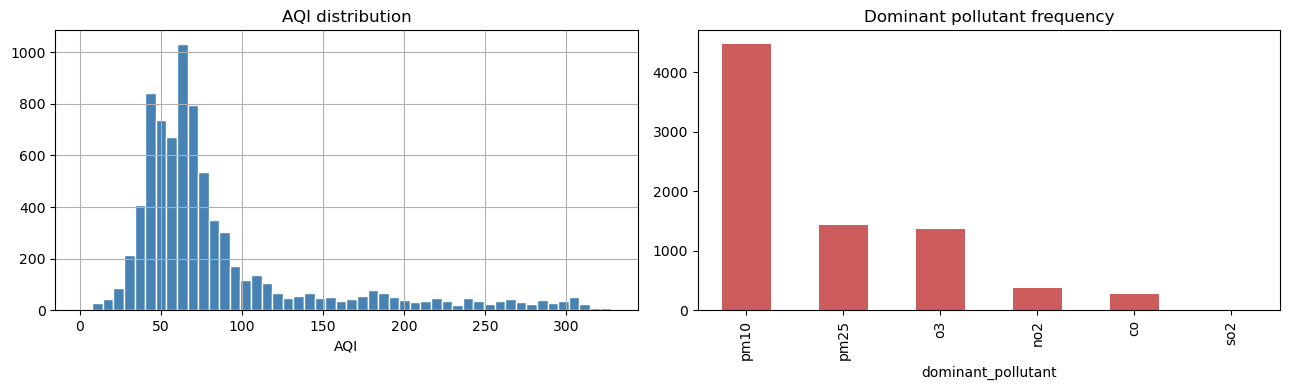

In [11]:
# Sanity checks

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
clean['AQI'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('AQI distribution')
axes[0].set_xlabel('AQI')

clean['dominant_pollutant'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Dominant pollutant frequency')
plt.tight_layout()
plt.show()

In [12]:
# Save file

import os
os.makedirs("../data/processed", exist_ok=True)
clean.to_csv(OUT_PATH, index=False)
print(f"Saved {len(clean)} rows to {OUT_PATH}")

Saved 7940 rows to ../../datasets/processed/aqi_hourly_clean.csv
